In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

df = pd.read_csv(r"C:\Users\hp\Desktop\AIDS\AIDS\drug200.csv")
print("Drug Dataset:\n")
df

Drug Dataset:



,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [14]:
df.dropna(axis=0, inplace=True)

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])
df['Drug'] = le.fit_transform(df['Drug'])

x = df.drop(['Drug'],axis=1)
y = df['Drug']
features = x.columns

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.40,random_state=42)

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.fit_transform(xtest)

model = LogisticRegression(max_iter=1000)
model.fit(xtrain_scaled,ytrain)

y_pred = model.predict(xtest_scaled)

acc = accuracy_score(y_pred,ytest) 
print(f"\nAccuracy score : {acc*100:.2f} %")

conf_matrix = confusion_matrix(ytest,y_pred)
print("\nConfusion Matrix:\n",conf_matrix)


Accuracy score : 88.75 %

Confusion Matrix:
 [[ 9  1  0  0  0]
 [ 1  5  0  0  0]
 [ 0  0  5  0  1]
 [ 0  1  0 22  2]
 [ 0  2  0  1 30]]


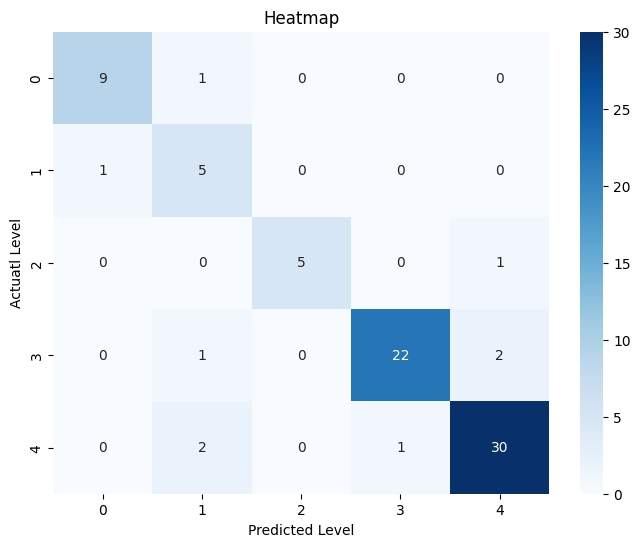

In [21]:
plt.figure(figsize=(8,6))
sn.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap')
plt.xlabel('Predicted Level')
plt.ylabel('Actuatl Level')
plt.show()

In [19]:
new_data = pd.DataFrame ({
    'Age' : [23],
    'Sex' : [0],
    'BP' : [0],
    'Cholesterol' : [0],
    'Na_to_K' : [25.355] })
xt = model.predict(new_data)
print("Y predicted : ",xt)
print("Y actual : ",y[0])

Y predicted :  [4]
Y actual :  4


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


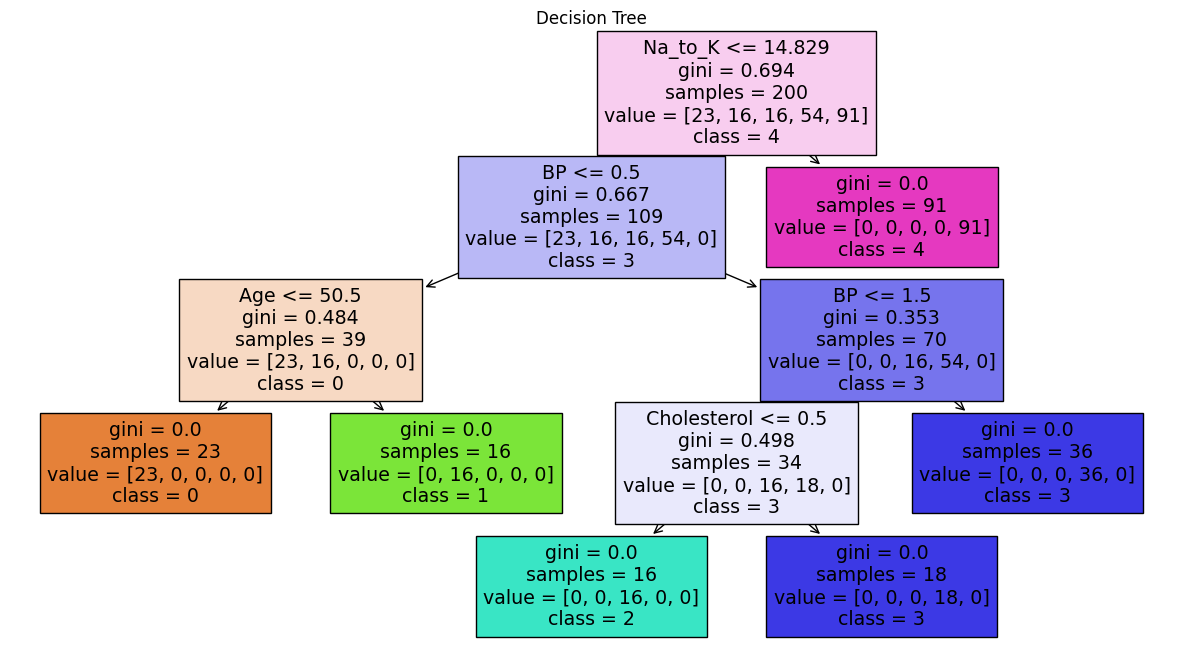

In [29]:
dtree = DecisionTreeClassifier()
dtree.fit(x,y)

plt.figure(figsize=(15,8))
tree.plot_tree(dtree, feature_names=features, filled=True, class_names=[str(c) for c in set(y)])
plt.title("Decision Tree")
plt.show()